In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
data_path = '../../Data'
data_cleansed = {}
files = sorted([f for f in os.listdir(data_path) if f.endswith('.csv')])

for file in files:
    file_full_path = os.path.join(data_path, file)

    if os.path.exists(file_full_path):
        df_temp = pd.read_csv(file_full_path)
        
        # Sửa tên theo ý bạn: df_<name>
        df_name = 'df_' + file.replace('.csv', '')
        
        # Lưu vào đúng dictionary data_cleansed
        data_cleansed[df_name] = df_temp.copy()

        print(f"✅ Đã tạo bản sao: {df_name}")
    else:
        print(f"❌ Không tìm thấy: {file} tại {file_full_path}")
print(f"\nSẵn sàng: {len(data_cleansed)} bảng.")


✅ Đã tạo bản sao: df_customers
✅ Đã tạo bản sao: df_geography
✅ Đã tạo bản sao: df_inventory


C:\Users\ngami\AppData\Local\Temp\ipykernel_36884\4234836259.py:9: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(file_full_path)


✅ Đã tạo bản sao: df_order_items
✅ Đã tạo bản sao: df_orders
✅ Đã tạo bản sao: df_payments
✅ Đã tạo bản sao: df_products
✅ Đã tạo bản sao: df_promotions
✅ Đã tạo bản sao: df_returns
✅ Đã tạo bản sao: df_reviews
✅ Đã tạo bản sao: df_sales
✅ Đã tạo bản sao: df_sample_submission
✅ Đã tạo bản sao: df_shipments
✅ Đã tạo bản sao: df_web_traffic

Sẵn sàng: 14 bảng.


In [3]:
# Lấy các bảng ra từ dictionary
df_items = data_cleansed['df_order_items']
df_promo = data_cleansed['df_promotions']
df_prod = data_cleansed['df_products']
# Bước 1: Kết nối đơn hàng với sản phẩm để lấy Category và Price gốc
df_merged = df_items.merge(df_prod[['product_id', 'category', 'price', 'product_name']], 
                           on='product_id', how='left')

# Bước 2: Kết nối với bảng Promotions để lấy thông tin chiến dịch
# Lưu ý: Ta merge cho promo_id chính, bạn có thể làm tương tự cho promo_id_2 nếu muốn
df_merged = df_merged.merge(df_promo, left_on='promo_id', right_on='promo_id', how='left')
df_merged = df_merged.merge(df_promo, left_on='promo_id_2', right_on='promo_id', how='left', suffixes=('', '_p2'))

# Bước 3: Tính toán các chỉ số bổ trợ
df_merged['revenue_actual'] = df_merged['quantity'] * df_merged['unit_price']
df_merged['revenue_before_discount'] = df_merged['quantity'] * df_merged['price']
df_merged['is_promo'] = (df_merged['promo_id'].notna()|df_merged['promo_id_2'].notna()).map({True: 'Có KM', False: 'Không KM'})

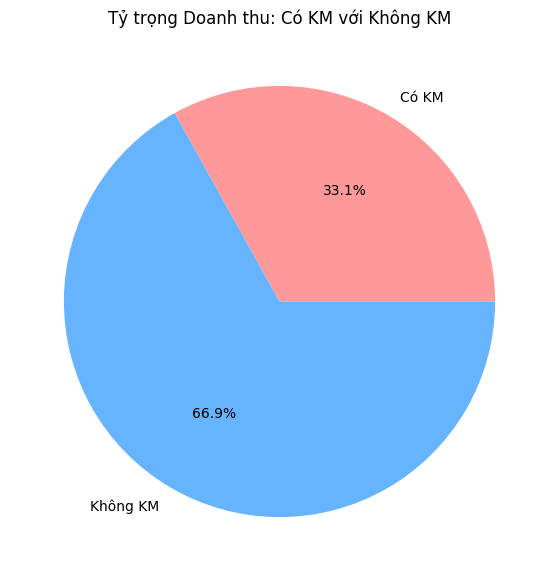

In [4]:
plt.figure(figsize=(7, 7))
revenue_by_promo = df_merged.groupby('is_promo')['revenue_actual'].sum()
plt.pie(revenue_by_promo, labels=revenue_by_promo.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title('Tỷ trọng Doanh thu: Có KM với Không KM')
plt.show()

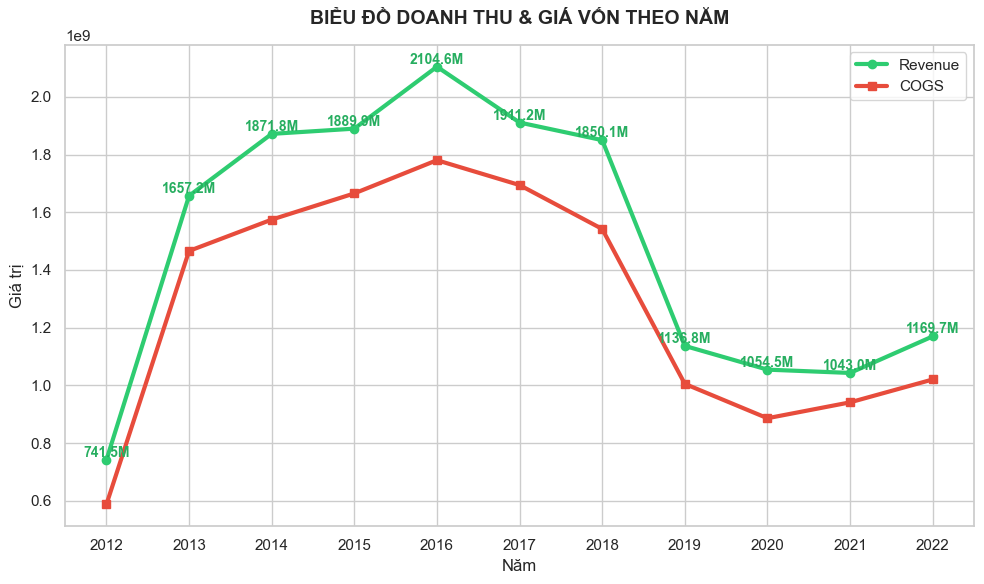

In [5]:
df_sales = data_cleansed['df_sales']
df_sales['Date'] = pd.to_datetime(df_sales['Date'])

# Tạo cột Year và tính tổng theo năm
df_yearly = df_sales.groupby(df_sales['Date'].dt.year).agg({
    'Revenue': 'sum',
    'COGS': 'sum'
}).reset_index()

# 2. Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Vẽ đường Revenue & COGS theo Năm
plt.plot(df_yearly['Date'], df_yearly['Revenue'], marker='o', label='Revenue', color='#2ecc71', linewidth=3)
plt.plot(df_yearly['Date'], df_yearly['COGS'], marker='s', label='COGS', color='#e74c3c', linewidth=3)

# 3. Trang trí
plt.title('BIỂU ĐỒ DOANH THU & GIÁ VỐN THEO NĂM', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Giá trị', fontsize=12)

# Hiển thị số liệu (Data Labels) theo đơn vị tỷ (hoặc triệu tùy ông)
for i in range(len(df_yearly)):
    plt.text(df_yearly['Date'][i], df_yearly['Revenue'][i], f"{df_yearly['Revenue'][i]/1e6:.1f}M", 
             va='bottom', ha='center', fontsize=10, color='#27ae60', fontweight='bold')

# Fix trục X chỉ hiển thị số năm nguyên (2012, 2013...)
plt.xticks(df_yearly['Date'].astype(int)) 

plt.legend()
plt.tight_layout()
plt.show()

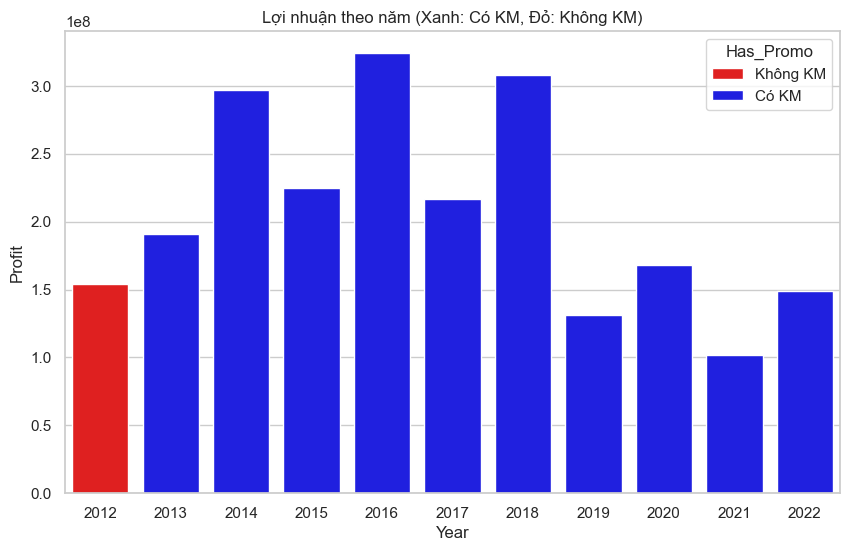

In [7]:
# 1. Chuẩn bị dữ liệu
df_sales = data_cleansed['df_sales']
df_promo = data_cleansed['df_promotions']

df_sales['Date'] = pd.to_datetime(df_sales['Date'])
df_promo['start_date'] = pd.to_datetime(df_promo['start_date'])
df_promo['end_date'] = pd.to_datetime(df_promo['end_date'])

# 2. Xác định các năm có KM
years_with_promo = set()
for _, row in df_promo.iterrows():
    s_yr = row['start_date'].year
    e_yr = row['end_date'].year
    for yr in range(s_yr, e_yr + 1):
        years_with_promo.add(yr)

# 3. Tính lợi nhuận theo năm
df_yearly = df_sales.groupby(df_sales['Date'].dt.year).agg({
    'Revenue': 'sum',
    'COGS': 'sum'
}).reset_index()

df_yearly.columns = ['Year', 'Revenue', 'COGS']
df_yearly['Profit'] = df_yearly['Revenue'] - df_yearly['COGS']
df_yearly['Has_Promo'] = df_yearly['Year'].apply(lambda x: 'Có KM' if x in years_with_promo else 'Không KM')

# 4. Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(data=df_yearly, x='Year', y='Profit', hue='Has_Promo', 
            palette={'Có KM': 'blue', 'Không KM': 'red'})

plt.title('Lợi nhuận theo năm (Xanh: Có KM, Đỏ: Không KM)')
plt.show()